---
INSEA - Institut Nationale de Statistiques et d'Economie Appliquée

---
<h1 align="center"> Méthodes alternatives de la régression </h1>

*Par : Hatim Rakkal - Mourad Bahaddou*

---

**Objectif :** Réaliser un script manuel de l'RCP et de la régression Ridge.

***




### 1 - Régression sur composantes principales RCP :

On commence par importer les bibliothèques nécessaire :

In [287]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [288]:
data = pd.read_excel("C:\\data\\Concrete_Data.xls", sheet_name=0, engine="xlrd")

# Afficher les premières lignes du DataFrame pour vérification 

data

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


In [289]:
X,Y = data.to_numpy()[:,:-1], data.to_numpy()[:,-1]
X

array([[ 540. ,    0. ,    0. , ..., 1040. ,  676. ,   28. ],
       [ 540. ,    0. ,    0. , ..., 1055. ,  676. ,   28. ],
       [ 332.5,  142.5,    0. , ...,  932. ,  594. ,  270. ],
       ...,
       [ 148.5,  139.4,  108.6, ...,  892.4,  780. ,   28. ],
       [ 159.1,  186.7,    0. , ...,  989.6,  788.9,   28. ],
       [ 260.9,  100.5,   78.3, ...,  864.5,  761.5,   28. ]])

Il faut tout d'abord centrer et réduire $X$ pour trouver des résultats cohérantes.

In [290]:
moyennes = np.mean(X,axis=0) # Les moyennes de chaque colonne
ecart_types = np.std(X,axis=0) # Les ecart-types de chaque colonne

Xcr = (X-moyennes) / ecart_types # Centrer et réduire les données
n,d = Xcr.shape # n : La taille de l'echantillion | d : Le nombre des variables explicatives



À l'aide de la formule
$$
\textrm{Cov}(X_{cr}) = \dfrac{1}{n-1} X_{cr}^\top X_{cr}
$$
On peut calculer la matrice de la variance manuellement.

In [291]:
# l'estimateur empirique de la variance
Cov = (Xcr.T @ Xcr) / (n-1)

In [292]:
valeurs_propres, vecteurs_propres = np.linalg.eigh(Cov)
# Les valeurs propres et les vecteurs propres sont triés par ordre croissant
valeurs_propres, vecteurs_propres = valeurs_propres[::-1], vecteurs_propres[:,::-1] # Inverser l'ordre

In [293]:
P = vecteurs_propres
Lambda = np.diag(valeurs_propres)

On a : $\textrm{Cov}(X_{cr}) = P \Lambda P^\top$

La variance retenue par les $k$ premiers composantes est donnée par : 
$$
\dfrac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i}
$$

In [294]:
def variance_retenue(k) :
    return np.sum(valeurs_propres[:k]) / np.sum(valeurs_propres)

In [318]:
k=1
while variance_retenue(k)<0.95:
    k+=1
print(f"Le nombre de variables après réduction : {k}")

Le nombre de variables après réduction : 6


In [296]:
P_k = P[:,:k]
W_k = Xcr @ P_k
W_k.shape

(1030, 6)

On applique les relations vues dans le document.

In [297]:
coefficients_rcp = np.linalg.inv(W_k.T @ W_k) @ W_k.T @ Y
intercept_rcp = np.mean(Y) - np.dot( np.mean(W_k,axis=0) , coefficients_rcp )

In [298]:
vec_intercept_rcp = np.array([intercept_rcp for i in range(n)])
Y_predicted = vec_intercept_rcp + W_k @ coefficients_rcp
print(Y,Y_predicted)

[79.98611076 61.88736576 40.26953526 ... 23.69660064 32.76803638
 32.40123514] [50.13612704 49.93930996 57.71212523 ... 25.86642343 36.90208521
 33.87147626]


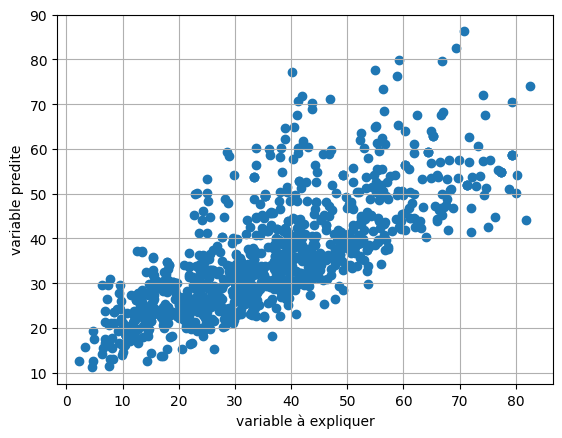

In [323]:
plt.scatter(Y,Y_predicted)
plt.xlabel("variable à expliquer")
plt.ylabel("variable predite")
plt.grid()
plt.show()

In [300]:
(Xcr * ecart_types) + moyennes

array([[ 540. ,    0. ,    0. , ..., 1040. ,  676. ,   28. ],
       [ 540. ,    0. ,    0. , ..., 1055. ,  676. ,   28. ],
       [ 332.5,  142.5,    0. , ...,  932. ,  594. ,  270. ],
       ...,
       [ 148.5,  139.4,  108.6, ...,  892.4,  780. ,   28. ],
       [ 159.1,  186.7,    0. , ...,  989.6,  788.9,   28. ],
       [ 260.9,  100.5,   78.3, ...,  864.5,  761.5,   28. ]])

In [301]:
intercept = intercept_rcp - (moyennes / ecart_types) @ P_k @ coefficients_rcp
coefficients = P_k @ coefficients_rcp / ecart_types
intercept_rcp

np.float64(35.8178358261136)

In [302]:
SCR = np.sum((Y-Y_predicted)**2)
SCT = np.sum((Y-np.mean(Y))**2)
SCE = np.sum((Y_predicted-np.mean(Y))**2)

In [303]:
R_carre = SCE/SCT
R_carre

np.float64(0.5651274964358974)

In [304]:
R_ajuste = 1-(((n-1)/(n-d-1))*(1-R_carre)) 
R_ajuste

np.float64(0.5617200723139455)

In [305]:


estimation_var_erreur = SCE / (n-d-1)

In [306]:
from scipy.stats import t
print(f"                                    ")

print("__________________________________________")
print(f"Intercept :           {intercept:.4f}")
print("__________________________________________")
print("coefficients :   ",end=" ")

for i in range(d) :
    print(i+1,"  ",round(coefficients[i],4)," ", end="\n                  ")

print("\n_________________________________________")

print(f"\nEstimation de la variance des erreurs : {estimation_var_erreur:.4f}")
print(f"Valeur de R carrée : {R_carre:.4f} | valeur de R carrée ajusté : {R_ajuste:.4f}")
print(f"Valeur de F_obs : {(n-d)/(d-1) * R_carre/(1-R_carre):.4f}")

                                    
__________________________________________
Intercept :           85.7467
__________________________________________
coefficients :    1    0.0537  
                  2    0.0244  
                  3    -0.0234  
                  4    -0.1817  
                  5    1.0182  
                  6    -0.0131  
                  7    -0.0399  
                  8    0.1036  
                  
_________________________________________

Estimation de la variance des erreurs : 158.9514
Valeur de R carrée : 0.5651 | valeur de R carrée ajusté : 0.5617
Valeur de F_obs : 189.7306


Test d'homoscédasticité

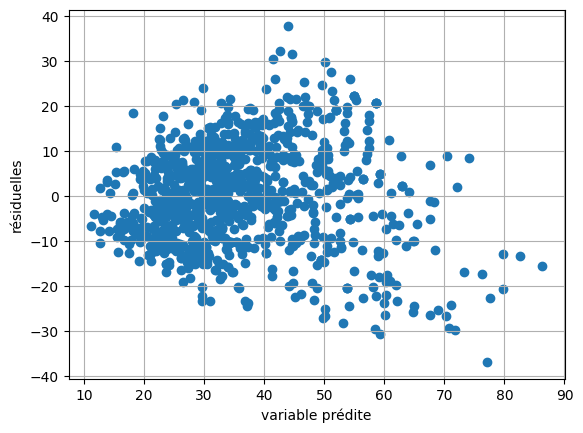

In [326]:
plt.scatter(Y_predicted,Y-Y_predicted)
plt.xlabel("variable prédite")
plt.ylabel("résiduelles")
plt.grid()
plt.show()

### 2. Régression Ridge :

In [307]:
colonne_uns = np.ones((X.shape[0],1))
X = np.column_stack([colonne_uns,X])
X.shape

(1030, 9)

In [308]:
def beta_ridge(Y,X,lambda_) :
    return np.linalg.inv(X.T@X + lambda_ * np.eye(d+1)) @ X.T @ Y

In [309]:
def beta_MCO(Y,X) :
    return beta_ridge(Y,X,0)

In [310]:
lambda_ = 0.1
R = (X.T@X+lambda_*np.eye(d+1))/n
VIFs = np.array([1/(1-R[i,i]**2) for i in range(d)])


In [311]:
Y_predicted_ridge = X@beta_ridge(Y,X,lambda_) 

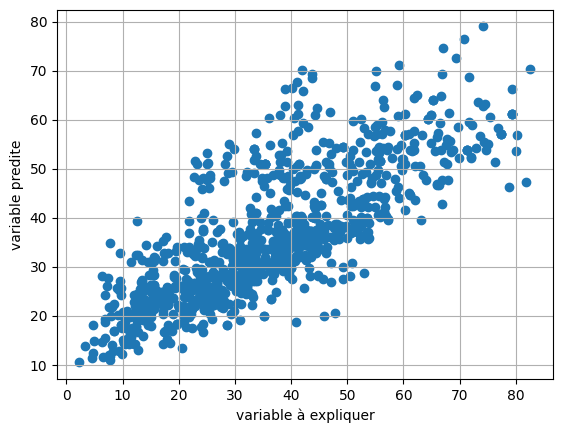

In [324]:
plt.scatter(Y,Y_predicted_ridge)
plt.xlabel("variable à expliquer")
plt.ylabel("variable predite")
plt.grid()
plt.show()

In [313]:
SCT_ridge = sum((Y-np.mean(Y))**2)
SCE_ridge = sum((Y_predicted_ridge-np.mean(Y_predicted_ridge))**2)

SCR_ridge = sum((Y_predicted_ridge-Y)**2)


In [314]:
coefficients = beta_ridge(Y,X,lambda_)
estimation_var_erreur = SCR_ridge / (n-d-1)
estimation_var_coefficients = estimation_var_erreur * np.linalg.inv(X.T@X + lambda_*np.eye(d+1))@X.T@X@np.linalg.inv(X.T@X + lambda_*np.eye(d+1))
estimation_var_intercept = estimation_var_coefficients[0,0]

In [315]:
R_carre = 1 - (SCR_ridge / SCT_ridge)
R_carre
R_ajuste = 1 - (n-1)*(1-R_carre)/(n-d-1)

In [316]:
from scipy.stats import t
print(f"                                    Variances        t-value          p(>|t|)")
t_value0 = round(intercept/np.sqrt(estimation_var_intercept),4)
p_value0 = round(2 * (1 - t.cdf(abs(t_value0), df=30)),4)
print("______________________________________________________________________________")
print(f"Intercept :           {intercept:.4f}",f"       {estimation_var_intercept:.4f}",f"        {t_value0}",f"         {p_value0}")
print("______________________________________________________________________________")
print("coefficients :   ",end=" ")

for i in range(d) :
    print(i+1,"  ",round(coefficients[i],4)," ", end=(12-len(str(round(coefficients[i],4))))*" ")
    var = round(estimation_var_coefficients[i,i],4)
    print(var,end=(17-len(str(var)))*" ")
    t_value = round(coefficients[i]/np.sqrt(estimation_var_coefficients[i,i]),4)
    print(t_value,end=(17-len(str(t_value)))*" ")
    p_value = round(2 * (1 - t.cdf(abs(t_value), df=30)) , 4)
    print(p_value,end="\n                  ")

print("\n_______________________________________________________________________________")

print(f"\nEstimation de la variance des erreurs : {estimation_var_erreur:.4f}")
print(f"Valeur de R carrée : {R_carre:.4f} | valeur de R carrée ajusté : {R_ajuste:.4f}")
print(f"Valeur de F_obs : {(n-d)/(d-1) * R_carre/(1-R_carre):.4f}")

                                    Variances        t-value          p(>|t|)
______________________________________________________________________________
Intercept :           85.7467        258.5582         5.3326          0.0
______________________________________________________________________________
coefficients :    1    -14.0078      258.5582         -0.8711          0.3906
                  2    0.1173        0.0              19.0683          0.0
                  3    0.1009        0.0001           13.6265          0.0
                  4    0.0846        0.0001           8.5748           0.0
                  5    -0.163        0.0008           -5.9347          0.0
                  6    0.2799        0.0081           3.1075           0.0041
                  7    0.015         0.0              2.4218           0.0217
                  8    0.0167        0.0              2.3607           0.0249
                  
___________________________________________________________

Test d'homoscédasticité :

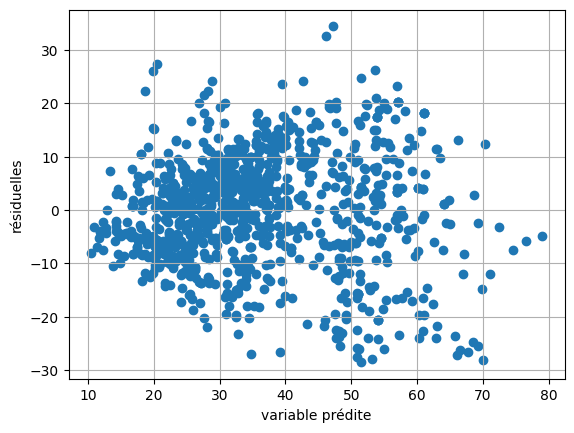

In [325]:
plt.scatter(Y_predicted_ridge,Y-Y_predicted_ridge)
plt.xlabel("variable prédite")
plt.ylabel("résiduelles")
plt.grid()
plt.show()